<a href="https://colab.research.google.com/github/arjun-1238/Machine-Learning-Models/blob/main/Naive_Byes_on_Spam_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
df=pd.read_csv("/content/spam.csv",encoding="latin")
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
df=df.rename(columns={"Category":"spam","Message":"text"})

In [32]:
from sklearn.preprocessing import LabelEncoder
en=LabelEncoder()
df["spam"]=en.fit_transform(df["spam"])
df.head(5)

,spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
x=cv.fit_transform(df["text"])
df.head(5)

,spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [34]:

y=df["spam"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [35]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)

MultinomialNB()

In [36]:
predict=model.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_test,predict))
print(classification_report(y_test,predict))
print(confusion_matrix(y_test,predict))

0.9811659192825112
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.92      0.94      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

[[954  12]
 [  9 140]]


In [38]:
from sklearn.naive_bayes import BernoulliNB
model=BernoulliNB()
model.fit(x,y)
predict1=model.predict(x_test)
print(accuracy_score(y_test,predict1))
print(classification_report(y_test,predict1))
print(confusion_matrix(y_test,predict1))

0.9874439461883409
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       1.00      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115

[[966   0]
 [ 14 135]]


In [43]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x,y)
predict2=model.predict(x_test)
print(accuracy_score(y_test,predict2))
print(classification_report(y_test,predict2))
print(confusion_matrix(y_test,predict2))

0.9955156950672646
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       1.00      0.97      0.98       149

    accuracy                           1.00      1115
   macro avg       1.00      0.98      0.99      1115
weighted avg       1.00      1.00      1.00      1115

[[966   0]
 [  5 144]]


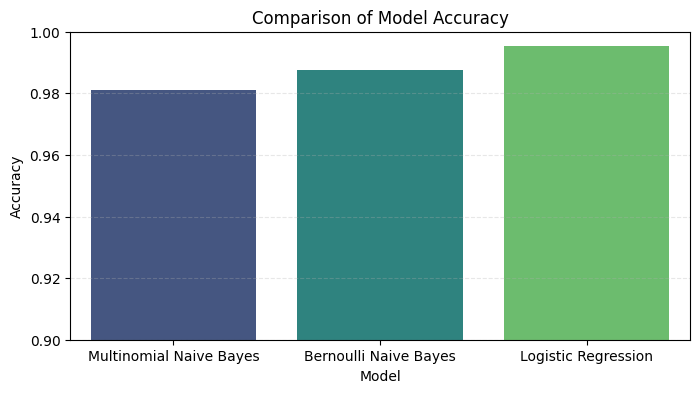

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Calculate accuracy scores for each model
accuracy_mnb = accuracy_score(y_test, predict)
accuracy_bnb = accuracy_score(y_test, predict1)
accuracy_lr = accuracy_score(y_test, predict2)

model_performance = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Bernoulli Naive Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_mnb, accuracy_bnb, accuracy_lr]})

plt.figure(figsize=(8,4))
sns.barplot(x='Model', y='Accuracy', data=model_performance, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Model Accuracy')
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()